In [1]:
import pandas as pd
import networkx as nx
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt 

import graph_maker, centrality_maker

In [2]:
with open('data/abyss_graphs/graph_2.pickle', 'rb') as f:
    G = joblib.load(f)

for u, v, data in G.edges(data=True):
    print(data)

{'weight_use': 4.0, 'weight_has': 31209.0}
{'weight_use': 35.0, 'weight_has': 25257.0}
{'weight_use': 320.0, 'weight_has': 421419.0}
{'weight_use': 25.0, 'weight_has': 108792.0}
{'weight_use': 14.0, 'weight_has': 23367.0}
{'weight_use': 11.0, 'weight_has': 24600.0}
{'weight_use': 339.0, 'weight_has': 176988.0}
{'weight_use': 6.0, 'weight_has': 10077.0}
{'weight_use': 17.0, 'weight_has': 113493.0}
{'weight_use': 7.0, 'weight_has': 9606.0}
{'weight_use': 1.0, 'weight_has': 32397.0}
{'weight_use': 87.0, 'weight_has': 136713.0}
{'weight_use': 6131.0, 'weight_has': 1277946.0}
{'weight_use': 7.0, 'weight_has': 59394.0}
{'weight_use': 104.0, 'weight_has': 109197.0}
{'weight_use': 303.0, 'weight_has': 227436.0}
{'weight_use': 12.0, 'weight_has': 18930.0}
{'weight_use': 18.0, 'weight_has': 14706.0}
{'weight_use': 13.0, 'weight_has': 15237.0}
{'weight_use': 16.0, 'weight_has': 129336.0}
{'weight_use': 15.0, 'weight_has': 98163.0}
{'weight_use': 155.0, 'weight_has': 276867.0}
{'weight_use': 18.0,

In [3]:
abyss_data = graph_maker.get_abyss_rank_activity()

abyss_betweenness_df, abyss_eigenvector_df = (
    centrality_maker.compute_centrality_matrices(
        base_dir="data/abyss_graphs",
        output_name_prefix="abyss",
        patch_labels=abyss_data["Patch Label"],
    )
)

Computed and saved centrality matrices for abyss


In [17]:
abyss_data["Patch Label"][[47, 48, 50]]

47    5.8 I
48    6.0 I
50    6.1 I
Name: Patch Label, dtype: object

In [18]:
abyss_data = graph_maker.get_abyss_rank_activity()

stygian_betweenness_df, stygian_eigenvector_df = (
    centrality_maker.compute_centrality_matrices(
        base_dir="data/stygian_graphs",
        output_name_prefix="stygian",
        patch_labels=abyss_data["Patch Label"][[47, 48, 50]],
    )
)

Computed and saved centrality matrices for stygian


In [ ]:
stygian_betweenness_df

In [4]:
def raw_cos(a, b):
    # Only consider indices where both a and b are non-null
    common_idx = a.notna() & b.notna()
    
    # Return 0 if no common ratings
    if common_idx.sum() == 0:
        return 0
    
    # Extract the common ratings
    v1 = a[common_idx].values
    v2 = b[common_idx].values
    
    
    # Compute cosine similarity
    numerator = np.dot(v1, v2)
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    
    if denom == 0:
        return 0
    
    return numerator / denom

In [5]:
eig_meta_changes = []
cols = abyss_eigenvector_df.columns

for i in range(len(cols) - 1):
    prev_col = cols[i]
    curr_col = cols[i + 1]

    prev_version = abyss_eigenvector_df[prev_col]
    curr_version = abyss_eigenvector_df[curr_col]

    eig_meta_changes.append(raw_cos(prev_version, curr_version))

eig_meta_dist = np.ones(len(eig_meta_changes))  - eig_meta_changes


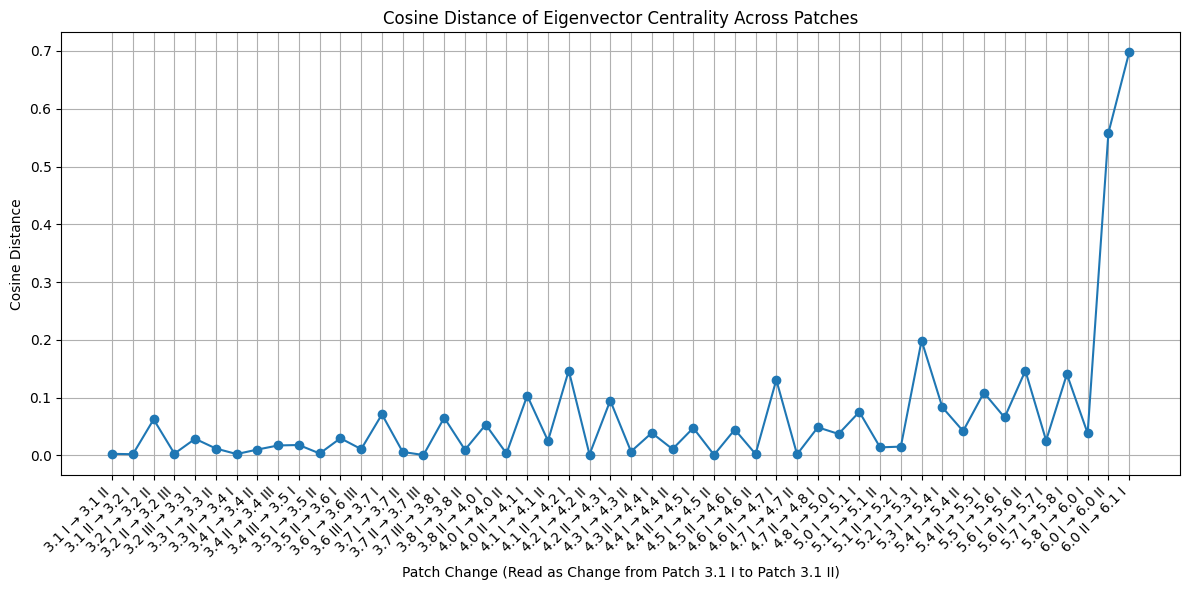

In [6]:
# Then because we are taking the change, we need a differenced
patches = abyss_eigenvector_df.columns
change_labels = [f"{patches[i]} → {patches[i+1]}" for i in range(len(patches)-1)]


plt.figure(figsize=(12, 6))
plt.plot(change_labels, eig_meta_dist, marker='o')

plt.title('Cosine Distance of Eigenvector Centrality Across Patches')
plt.xlabel('Patch Change (Read as Change from Patch 3.1 I to Patch 3.1 II)')
plt.ylabel('Cosine Distance')
plt.grid(True)

# Apply Patch_Labeled as tick labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [7]:
abyss_eigenvector_df.T.describe().T[['mean', '50%']].sort_values(by='50%', ascending=False)

,mean,50%
Xilonen,0.397125,0.430493
Furina,0.393780,0.398145
Bennett,0.353287,0.395283
Citlali,0.313142,0.329118
Mavuika,0.293868,0.321738
...,...,...
Amber,0.000263,0.000199
Freminet,0.000237,0.000140
Sethos,0.000174,0.000086
Xinyan,0.000087,0.000083


<Axes: >

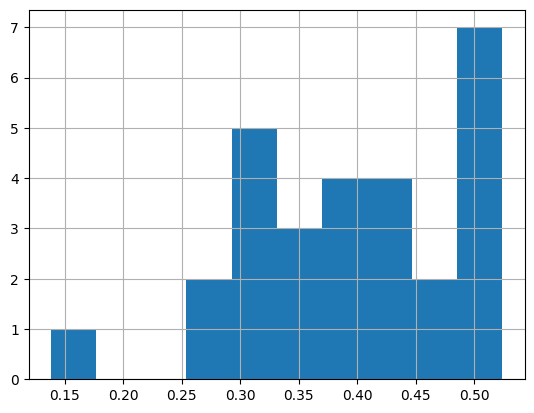

In [9]:
abyss_eigenvector_df.T['Furina'].dropna().hist()

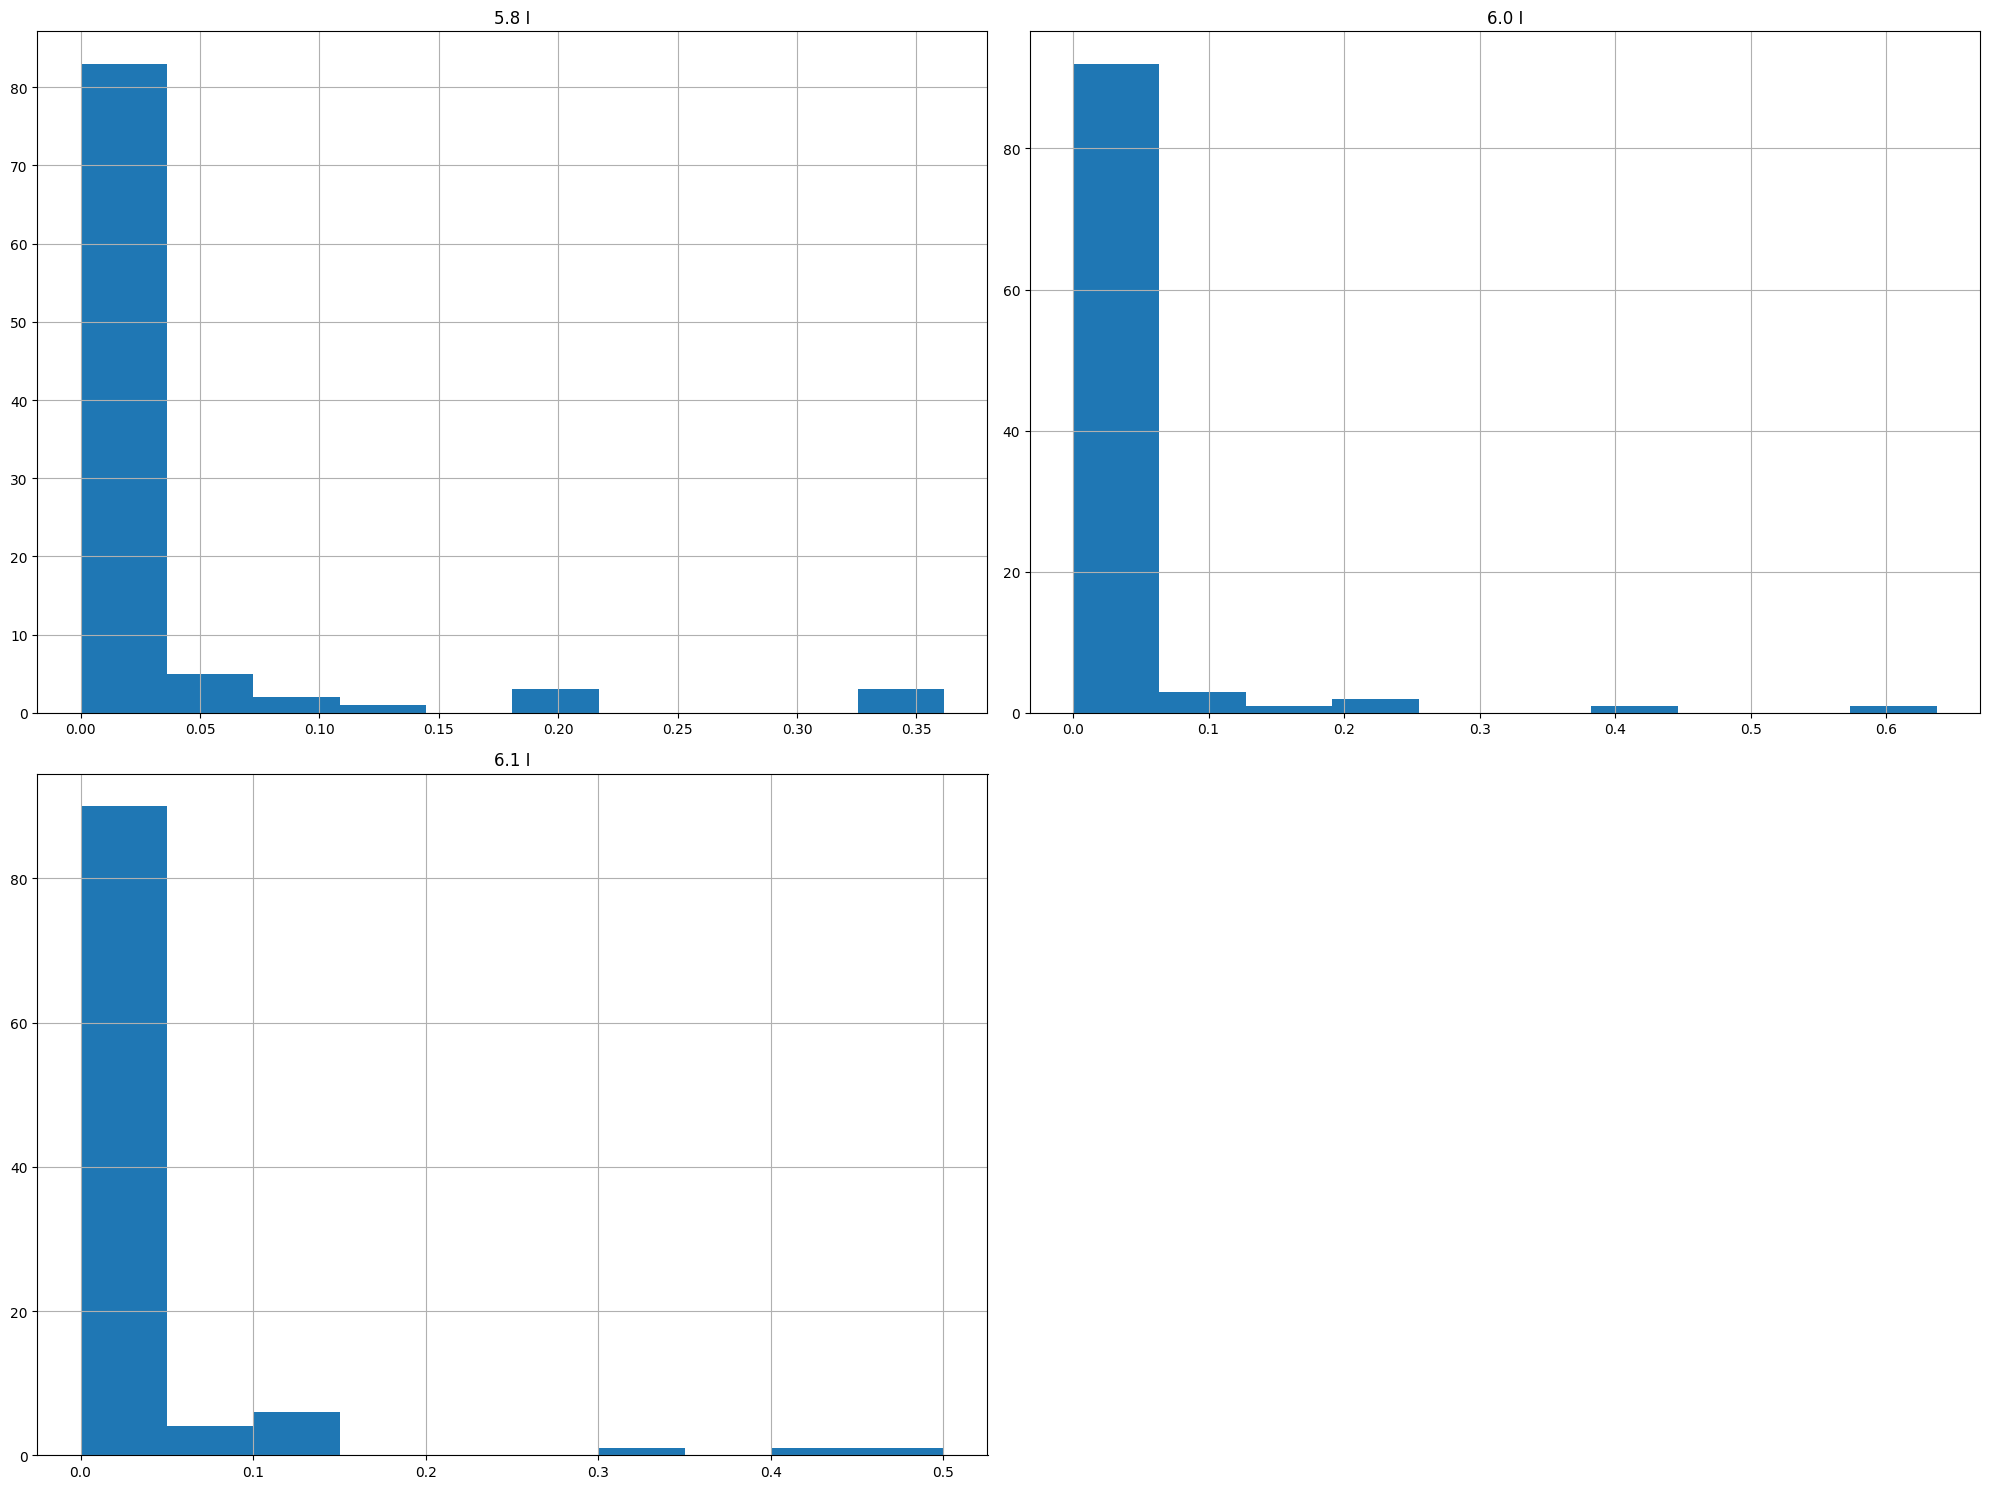

In [20]:
stygian_betweenness_df.hist(figsize=(20, 15))
plt.tight_layout()

In [9]:
# Total number of rows
n = close_log_df.shape[0]

# Compute split points
train_end = int(n * 0.7)           # 70% for training
val_end = train_end + int(n * 0.2) # next 20% for validation

# Create splits
train_df = close_log_df.iloc[:train_end]
val_df = close_log_df.iloc[train_end:val_end]
test_df = close_log_df.iloc[val_end:]

print(f"Training set: {train_df.shape[0]} rows ({train_df.shape[0]/n:.0%})")
print(f"Validation set: {val_df.shape[0]} rows ({val_df.shape[0]/n:.0%})")
print(f"Test set: {test_df.shape[0]} rows ({test_df.shape[0]/n:.0%})")


NameError: name 'close_log_df' is not defined

In [53]:
abyss_eigenvector_df.shape

(105, 51)

In [50]:
abyss_eigenvector_df[['3.5 II', '3.6 I']].dropna().head(50)

,3.5 II,3.6 I
Albedo,0.048729,0.028563
Alhaitham,0.123002,0.149500
Aloy,0.000703,0.001169
Amber,0.002747,0.001683
Arataki Itto,0.041034,0.033908
Barbara,0.060825,0.143514
Beidou,0.007786,0.007391
Bennett,0.194471,0.086855
Candace,0.005129,0.003962
Chongyun,0.006163,0.002580
